In [23]:
# Cell 1: relevant imports, paths, etc.

import json
import os
import time
import pandas as pd
import gseapy as gp
import numpy as np
import requests
from collections import defaultdict

# Setting up paths that will be reused
matrices_dir = r"D:\School\IITD\General\GBM_new\miner_output\output_matrices"
jsons_dir = r"D:\School\IITD\General\GBM_new\miner_output\output_jsons"

# Load json file containing regulons from earlier MINER run
with open(os.path.join(jsons_dir,"regulons.json")) as f:
    all_regulons = json.load(f)

In [24]:
# Cell 2: preprocessing, constructing the required mappings
# MINER has its own ID-mapping text file; using this to create a gene mapping from Ensembl ID to symbol

miner_dir = r"C:\Users\Amogh Kukreja\AppData\Roaming\Python\Python313\site-packages\miner"  
idmap_path = os.path.join(miner_dir, "data", "identifier_mappings.txt")
idmap = pd.read_csv(idmap_path, sep="\t", header=0)

# idmap has source data for multiple biomolecules (proteins, mRNA, genes)
# We filter to genes and only keep 2 columns: Preferred Name (Gene name) and Name (Ensembl ID)
gene_name_map = idmap[idmap['Source'] == 'Gene Name'][['Preferred_Name', 'Name']]

# Creates a mapping dict {name: Ensembl}
symbol_to_ensembl = dict(zip(gene_name_map['Name'], gene_name_map['Preferred_Name']))

# Reverses dict
ensembl_to_symbol = {v: k for k, v in symbol_to_ensembl.items()}


In [25]:
# Cell 3: loading file containing disease-relevant regulons and extracting all disease-relevant genes
# Goal is to check which of these genes are enriched with GBM hallmarks using CBioPortal, so that we can identify potential new drivers of GBM

disease_rel = pd.read_csv(r"D:\School\IITD\General\GBM_new\miner_output\output_matrices\final_disease_relevant_regulons.csv")
# Converts it to list
drr = disease_rel.iloc[:,0].tolist()

# Column name but is actually a regulon, was not appended earlier
drr.append(1378)

#print(drr[:5])
#print(len(drr))

# Convert str to int everywhere
all_regulons_final = {int(a):b for a,b in all_regulons.items()}

# Create mapping of all disease relevant regulons to the genes they contain
disease_rel_filtered = {regulon:genelist for regulon, genelist in all_regulons_final.items() if regulon in drr}

# Convert from Ensembl to gene symbol 
disease_rel_symbols = {}
for r,genes in disease_rel_filtered.items():
    
    genes = [ensembl_to_symbol.get(g, g) for g in genes]
    disease_rel_symbols[r] = genes
    
# List of lists
genelists = list(disease_rel_symbols.values())
final_genes = []

for i in genelists:

    # Creates a final flattened list of genes
    final_genes += i

# Convert to set to remove dupes
final_genes = list(set(final_genes))
print(len(final_genes))

1766


In [26]:
# Cell 4: running hallmark enrichment on the disease-relevant genes

def run_hallmark_enrichment(gene_list, organism='homo sapiens'):

    # Uses gseapy to call Enrichr API and carries out ORA (Overrepresentation Analysis)
    # gene_sets is a list of cancer hallmark gene sets
    # API tries to find if overlap between gene_list and gene_sets is higher than expected by chance
    
    enr = gp.enrichr(
        gene_list=gene_list,
        gene_sets='MSigDB_Hallmark_2020',
        organism=organism,
        outdir=None,
        no_plot=True
    )

    # Sorts by p-value so the most enriched genes are at the top
    results = enr.results.sort_values('Adjusted P-value')
    return results

print("\nRunning Hallmark enrichment...")
enr_results = run_hallmark_enrichment(final_genes)

print(f"\nTop enriched hallmarks (FDR <= 0.05):")

# Filter to signficantly enriched genes
sig = enr_results[enr_results['Adjusted P-value'] <= 0.05]
print(sig[['Term', 'Overlap', 'P-value', 'Adjusted P-value', 'Genes']].to_string())

# Save
enr_results.to_csv(os.path.join(matrices_dir, "gbmminer_hallmark_enrichment.csv"), index=False)
sig.to_csv(os.path.join(matrices_dir, "gbmminer_hallmark_enrichment_significant.csv"), index=False)
print(f"\nSaved. Significant hallmarks: {len(sig)}")

enriched_genes = set()
for genes_str in sig['Genes']:

    # Splits by semicolon to extract all unique enriched gene names and adds them to a set
    enriched_genes.update(genes_str.split(';'))

print(f"Unique genes implicated in significant hallmarks: {len(enriched_genes)}")

# Converts set to list and then to csv of enriched genes
pd.Series(list(enriched_genes)).to_csv(
    os.path.join(matrices_dir, "hallmark_enriched_genes.csv"), 
    index=False, header=False
)


Running Hallmark enrichment...

Top enriched hallmarks (FDR <= 0.05):
                                 Term  Overlap       P-value  Adjusted P-value                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            Genes
0   Epithelial Mesenchymal Transition  110/200  6.725701e-63      3.362850e-61  OXTR;SPARC;COL16A1;WIPF1;SERPINE1;TNC;PLOD3;PLOD1;SAT1;PVR;LOXL1;MYLK;LOXL2;EFEMP2;LGALS1;CDH2;BASP1;TGM2;POSTN;TPM4;TPM2;TPM1;IG

In [27]:
# Cell 5: breakdown of which genes hit which hallmarks

# Defaultdict: accessing a missing key creates an empty list
gene_hallmark_map = defaultdict(list)

# Iterates through each significant gene and 
for _, row in sig.iterrows():
    for gene in row['Genes'].split(';'):
        gene_hallmark_map[gene].append(row['Term'])

gene_hallmark_df = pd.DataFrame([
    {'Gene': gene, 'Hallmarks': '; '.join(hallmarks), 'N_Hallmarks': len(hallmarks)}
    for gene, hallmarks in gene_hallmark_map.items()
]).sort_values('N_Hallmarks', ascending=False)

print(f"Genes hitting multiple hallmarks:")
print(gene_hallmark_df.head(10).to_string())

gene_hallmark_df.to_csv(os.path.join(matrices_dir, "gene_hallmark_breakdown.csv"), index=False)

Genes hitting multiple hallmarks:
         Gene                                                                                                                                                                                                          Hallmarks  N_Hallmarks
49        IL6  Epithelial Mesenchymal Transition; Inflammatory Response; TNF-alpha Signaling via NF-kB; Allograft Rejection; Interferon Gamma Response; Apoptosis; IL-6/JAK/STAT3 Signaling; Hypoxia; Complement; UV Response Up           10
113    CDKN1A                              Inflammatory Response; TNF-alpha Signaling via NF-kB; Interferon Gamma Response; Apoptosis; Hypoxia; mTORC1 Signaling; Myogenesis; p53 Pathway; E2F Targets; PI3K/AKT/mTOR  Signaling           10
4    SERPINE1                               Epithelial Mesenchymal Transition; Inflammatory Response; TNF-alpha Signaling via NF-kB; Hypoxia; Complement; Coagulation; UV Response Dn; Xenobiotic Metabolism; TGF-beta Signaling            9
148      IRF1 

In [34]:
# Set up internal IDs used by CBioPortal
cbio_base = "https://www.cbioportal.org/api"
study_id  = "gbm_tcga"
mut_profile = f"{study_id}_mutations"
sample_list = f"{study_id}_all"

genes = list(enriched_genes)  # 845 hallmark-enriched AND disease-relevant genes

# Total profiled samples in this sample list — needed as the denominator for mutation frequency
resp = requests.get(f"{cbio_base}/sample-lists/{sample_list}", timeout=15)
resp.raise_for_status()
n_profiled_samples = len(resp.json()['sampleIds'])
print(f"Total samples in {sample_list}: {n_profiled_samples}")


def post_with_retry(url, json_payload, max_retries=3, timeout=30):
    
    for attempt in range(max_retries):
        try:
            resp = requests.post(
                url, json=json_payload,
                headers={"Content-Type": "application/json"},
                timeout=timeout
            )
        except requests.exceptions.RequestException as e:
            print(f"    [attempt {attempt+1}] network error: {e}")
            time.sleep(2 * (attempt + 1))
            continue
            
        # If API call succeeds, return the status code and parsed json code
        if resp.status_code == 200:
            return resp.status_code, resp.json(), None

        # 429 means too many requests; waits for  5 * (attempt number) seconds
        elif resp.status_code == 429:
            wait = 5 * (attempt + 1)
            print(f"    [attempt {attempt+1}] rate-limited (429), waiting {wait}s...")
            time.sleep(wait)
            continue

        # Working fine
        else:
            return resp.status_code, None, resp.text[:300]

    return None, None, "max retries exceeded"

def hugo_to_entrez(symbols, chunk_size=300):

    # Parses Hugo symbol and returns Entrez ID, 300 genes at a time

    symbol_to_entrez = {}

    # Iterates through the list of symbols provide, splitting it into chunks of 300
    for i in range(0, len(symbols), chunk_size):
        chunk = symbols[i:i+chunk_size]

        # Get json data for each gene
        status, data, err = post_with_retry(
            f"{cbio_base}/genes/fetch?geneIdType=HUGO_GENE_SYMBOL", chunk
        )

        # Raises error message if API call fails
        if status != 200:
            print(f"  FAILED genes/fetch at {i}: {err}")
            
            continue

        # Update the symbol_to_entrez dict
        for g in data:

            # Sets key to Hugo symbol and value to Entrez ID
            symbol_to_entrez[g['hugoGeneSymbol']] = g['entrezGeneId']

    return symbol_to_entrez

def get_mutation_records(entrez_ids, chunk_size=100):
    
    # Fetches raw mutation records via the confirmed-working /mutations/fetch endpoint
    
    all_records = []

    # Now iterate through the items of the dict returned by hugo_to_entrez 
    for i in range(0, len(entrez_ids), chunk_size):
        
        chunk = entrez_ids[i:i+chunk_size]

        # Get mutation data for each gene
        status, data, err = post_with_retry(
            f"{cbio_base}/molecular-profiles/{mut_profile}/mutations/fetch",
            {"sampleListId": sample_list, "entrezGeneIds": chunk}
        )

        # Error handling
        if status != 200:
            print(f"  FAILED mutations/fetch at {i}: {err}")
            continue

        # Add all new mutation records
        all_records.extend(data)
        
        # Progress indicator
        print(f"  Progress: {min(i+chunk_size, len(entrez_ids))}/{len(entrez_ids)} genes queried, "
              f"{len(all_records)} mutation records so far")
        
        time.sleep(0.2)
        
    return all_records


print("\nMapping HUGO symbols to Entrez IDs...")

# Create and then reverse mapping
hugo_to_entrez = hugo_to_entrez(genes)
entrez_to_hugo = {v: k for k, v in hugo_to_entrez.items()}
print(f"  Mapped {len(hugo_to_entrez)}/{len(genes)} genes")

# Keeping track of genes that haven't been mapped to Entrez ID
unmapped = set(genes) - set(hugo_to_entrez.keys())
if unmapped:
    
    print(f"  {len(unmapped)} genes not found in cBioPortal (outdated/alias symbols), e.g.: {list(unmapped)[:10]}")


print("\nFetching mutation records (this may take a few minutes for ~1750 genes)...")

# Get mutation data for each Entrez ID in the list
entrez_ids = list(entrez_to_hugo.keys())
records = get_mutation_records(entrez_ids)

print(f"\nTotal mutation records retrieved: {len(records)}")

# Builds per-gene mutation counts: counts UNIQUE samples with >=1 mutation in that gene
# Each row contains Hugo symbol, number of cases where gene is mutated, mutation frequency
mut_df_raw = pd.DataFrame(records)

if mut_df_raw.empty:

    print("No mutation records returned at all — something is still wrong upstream.")

else:
    # This only contains genes with >= 1 mutation
    per_gene = (
        mut_df_raw.groupby('entrezGeneId')['sampleId']
        .nunique()
        .reset_index(name='numberOfAlteredCases')
    )
    per_gene['hugoGeneSymbol'] = per_gene['entrezGeneId'].map(entrez_to_hugo)

    # genes with 0 mutations don't appear in the groupby above; added back as 0
    all_symbols_df = pd.DataFrame({'hugoGeneSymbol': list(entrez_to_hugo.values())})
    mutation_df = all_symbols_df.merge(
        per_gene[['hugoGeneSymbol', 'numberOfAlteredCases']],
        on='hugoGeneSymbol', how='left'
    )

    # NaN values are the ones that aren't in both per_gene and all_symbols_df; they are replaced by 0
    mutation_df['numberOfAlteredCases'] = mutation_df['numberOfAlteredCases'].fillna(0).astype(int)

    # Aligning columns
    mutation_df['numberOfSamplesProfiled'] = n_profiled_samples
    mutation_df['alterationFrequency'] = mutation_df['numberOfAlteredCases'] / n_profiled_samples
    mutation_df = mutation_df.sort_values('alterationFrequency', ascending=False).reset_index(drop=True)

    # Summary of per-gene mutation data
    print(f"\nMutation frequency table shape: {mutation_df.shape}")
    print(mutation_df[['hugoGeneSymbol', 'numberOfAlteredCases', 'alterationFrequency']].head(15).to_string())

    # Saving data
    out_path = os.path.join(matrices_dir, "gbmminer_mutation_frequencies.csv")
    mutation_df.to_csv(out_path, index=False)
    print(f"\nSaved to {out_path}")

Total samples in gbm_tcga_all: 619

Mapping HUGO symbols to Entrez IDs...
  Mapped 844/845 genes
  1 genes not found in cBioPortal (outdated/alias symbols), e.g.: ['FAM102A']

Fetching mutation records (this may take a few minutes for ~1750 genes)...
  Progress: 100/844 genes queried, 101 mutation records so far
  Progress: 200/844 genes queried, 177 mutation records so far
  Progress: 300/844 genes queried, 254 mutation records so far
  Progress: 400/844 genes queried, 335 mutation records so far
  Progress: 500/844 genes queried, 449 mutation records so far
  Progress: 600/844 genes queried, 518 mutation records so far
  Progress: 700/844 genes queried, 630 mutation records so far
  Progress: 800/844 genes queried, 721 mutation records so far
  Progress: 844/844 genes queried, 772 mutation records so far

Total mutation records retrieved: 772

Mutation frequency table shape: (844, 4)
   hugoGeneSymbol  numberOfAlteredCases  alterationFrequency
0          COL6A3                    14 

In [35]:
# Build per-hallmark significance weights from `sig`
hallmark_weight = dict(zip(sig['Term'], -np.log10(sig['Adjusted P-value'])))

# Recompute gene -> hallmark list (same as before) but now also track weighted score
gene_hallmark_map = defaultdict(list)
gene_score = defaultdict(float)

for _, row in sig.iterrows():
    weight = hallmark_weight[row['Term']]
    for gene in row['Genes'].split(';'):
        gene_hallmark_map[gene].append(row['Term'])
        gene_score[gene] += weight

gene_rank_df = pd.DataFrame([
    {
        'Gene': gene,
        'WeightedScore': gene_score[gene],
        'N_Hallmarks': len(hallmarks),
        'Hallmarks': '; '.join(hallmarks)
    }
    for gene, hallmarks in gene_hallmark_map.items()
]).sort_values('WeightedScore', ascending=False).reset_index(drop=True)

# Dataframe consisting of gene name, score and number of hallmarks the gene appears in
top50 = gene_rank_df.head(50)
print(top50[['Gene', 'WeightedScore', 'N_Hallmarks']].to_string())

top50.to_csv(os.path.join(matrices_dir, "top50_hallmark_weighted_genes.csv"), index=False)
print(f"\nSaved top 50 to {os.path.join(matrices_dir, 'top50_hallmark_weighted_genes.csv')}")

         Gene  WeightedScore  N_Hallmarks
0         IL6     280.915636           10
1    SERPINE1     215.804749            9
2       PLAUR     211.263457            7
3       INHBA     196.290179            5
4      CDKN1A     193.345563           10
5        CD44     191.720911            8
6     TNFAIP3     191.478440            6
7      CXCL10     189.937431            7
8       TIMP1     188.861805            7
9        IRF1     182.365519            8
10       IL1B     180.725572            6
11        JUN     174.978506            6
12        FAS     168.849273            7
13        LIF     166.503163            6
14    GADD45B     159.983559            5
15      CXCL6     152.837390            4
16       RHOB     151.831668            5
17       CCL5     150.095750            5
18      VEGFA     150.086699            7
19      ITGB3     149.834420            5
20       IL4R     147.283067            6
21         F3     145.964904            6
22      ICAM1     143.940788      

In [38]:
def get_top_hallmarks(hallmark_list, top_n=2):
    ranked = sorted(hallmark_list, key=lambda h: hallmark_weight.get(h, 0), reverse=True)
    return '; '.join(ranked[:top_n])

gene_rank_df['Top_Hallmarks'] = gene_rank_df['Hallmarks'].apply(
    lambda h_str: get_top_hallmarks(h_str.split('; '))
)

# Sumarry: top 2 hallmarks per gene
print(gene_rank_df.columns.tolist())
print(gene_rank_df.head(3))

['Gene', 'WeightedScore', 'N_Hallmarks', 'Hallmarks', 'OT_GBM_Score', 'GBM_Status', 'Top_Hallmarks']
       Gene  WeightedScore  N_Hallmarks  \
0       IL6     280.915636           10   
1  SERPINE1     215.804749            9   
2     PLAUR     211.263457            7   

                                           Hallmarks  OT_GBM_Score  \
0  Epithelial Mesenchymal Transition; Inflammator...      0.113994   
1  Epithelial Mesenchymal Transition; Inflammator...      0.118383   
2  Epithelial Mesenchymal Transition; Inflammator...      0.090453   

                  GBM_Status  \
0  Known (moderate evidence)   
1  Known (moderate evidence)   
2        Weak prior evidence   

                                       Top_Hallmarks  
0  Epithelial Mesenchymal Transition; Inflammator...  
1  Epithelial Mesenchymal Transition; Inflammator...  
2  Epithelial Mesenchymal Transition; Inflammator...  


In [41]:
OT_URL = "https://api.platform.opentargets.org/api/v4/graphql"
GBM_EFO_ID = "EFO_0000519"

# Query Open Targets for ALL targets associated with GBM
# Uses pagination since there may be thousands of associated genes
assoc_query = """
query gbmTargets($efoId: String!, $page: Int!) {
  disease(efoId: $efoId) {
    associatedTargets(page: {index: $page, size: 500}) {
      count
      rows {
        target {
          approvedSymbol
        }
        score
        datatypeScores {
          id
          score
        }
      }
    }
  }
}
"""

all_associations = []
page = 0
total = None
max_retries = 5

print("Fetching GBM-associated targets from Open Targets...")
while True:
    for attempt in range(max_retries):
        try:
            resp = requests.post(
                OT_URL,
                json={"query": assoc_query, "variables": {"efoId": GBM_EFO_ID, "page": page}},
                timeout=60
            )
            if resp.status_code in (502, 503, 504):
                print(f"  Server error {resp.status_code} on page {page}, attempt {attempt+1}/{max_retries}, waiting...")
                time.sleep(10 * (attempt + 1))
                continue
            resp.raise_for_status()
            break
        except requests.exceptions.ReadTimeout:
            print(f"  Timeout on page {page}, attempt {attempt+1}/{max_retries}, retrying...")
            time.sleep(5 * (attempt + 1))
    else:
        print(f"  Failed page {page} after {max_retries} attempts, stopping here.")
        break

    data = resp.json()["data"]["disease"]["associatedTargets"]

    if total is None:
        total = data["count"]
        print(f"  Total GBM-associated targets in Open Targets: {total}")

    rows = data["rows"]
    if not rows:
        break

    all_associations.extend(rows)
    print(f"  Fetched {len(all_associations)}/{total}")
    page += 1
    time.sleep(0.5)  # more conservative pause

# Build mapping: gene symbol -> OT association score
ot_scores = {
    row["target"]["approvedSymbol"]: row["score"]
    for row in all_associations
}
print(f"\nDone. {len(ot_scores)} genes with GBM association scores in Open Targets.")

# Intersection with disease-relevant genes
gene_rank_df["OT_GBM_Score"] = gene_rank_df["Gene"].map(ot_scores).fillna(0.0)

# Classification thresholds (Open Targets scores are 0-1)
def classify(score):
    if score >= 0.5:
        return "Known (strong evidence)"
    elif score >= 0.1:
        return "Known (moderate evidence)"
    elif score > 0.0:
        return "Weak prior evidence"
    else:
        return "Novel Candidate"

gene_rank_df["GBM_Status"] = gene_rank_df["OT_GBM_Score"].apply(classify)

# Summary
print("\nClassification breakdown across all 845 hallmark-enriched genes:")
print(gene_rank_df["GBM_Status"].value_counts().to_string())

# Top 50 genes annotated with Open Targets data
top50 = gene_rank_df.head(50)[
    ["Gene", "N_Hallmarks", "Top_Hallmarks", "WeightedScore", "OT_GBM_Score", "GBM_Status"]
].copy()

print("\nTop 50 genes:")
print(top50.to_string(index=False))

# Save outputs
top50.to_csv(os.path.join(matrices_dir, "top50_genes_OT_annotated.csv"), index=False)

novel_df = gene_rank_df[
    gene_rank_df["GBM_Status"] == "Novel Candidate"
].sort_values("WeightedScore", ascending=False).reset_index(drop=True)

novel_df.to_csv(os.path.join(matrices_dir, "novel_candidates_OT.csv"), index=False)
print(f"\nNovel candidates (zero OT evidence): {len(novel_df)}")
print(f"Saved both files to {matrices_dir}")

Fetching GBM-associated targets from Open Targets...
  Total GBM-associated targets in Open Targets: 10037
  Fetched 500/10037
  Fetched 1000/10037
  Fetched 1500/10037
  Fetched 2000/10037
  Fetched 2500/10037
  Fetched 3000/10037
  Fetched 3500/10037
  Fetched 4000/10037
  Fetched 4500/10037
  Fetched 5000/10037
  Fetched 5500/10037
  Fetched 6000/10037
  Fetched 6500/10037
  Fetched 7000/10037
  Fetched 7500/10037
  Fetched 8000/10037
  Fetched 8500/10037
  Fetched 9000/10037
  Fetched 9500/10037
  Fetched 10000/10037
  Fetched 10037/10037

Done. 9650 genes with GBM association scores in Open Targets.

Classification breakdown across all 845 hallmark-enriched genes:
GBM_Status
Weak prior evidence          567
Known (moderate evidence)    147
Novel Candidate              128
Known (strong evidence)        3

Top 50 genes:
     Gene  N_Hallmarks                                                    Top_Hallmarks  WeightedScore  OT_GBM_Score                GBM_Status
      IL6           1

   Gene  WeightedScore  N_Hallmarks                                                    Top_Hallmarks
GADD45B     159.983559            5 Epithelial Mesenchymal Transition; TNF-alpha Signaling via NF-kB
   RTP4      75.716400            3                 Inflammatory Response; Interferon Gamma Response
 PDLIM5      73.159911            5                    TNF-alpha Signaling via NF-kB; UV Response Dn
  FBLN5      72.990081            2                Epithelial Mesenchymal Transition; UV Response Dn
  SCN1B      69.054071            2                         Inflammatory Response; KRAS Signaling Up
  GNA15      64.467610            2                                 Inflammatory Response; Apoptosis
   FZD8      62.378894            2    Epithelial Mesenchymal Transition; Wnt-beta Catenin Signaling
  MFAP5      60.473292            1                                Epithelial Mesenchymal Transition
  WIPF1      60.473292            1                                Epithelial Mesenchymal T

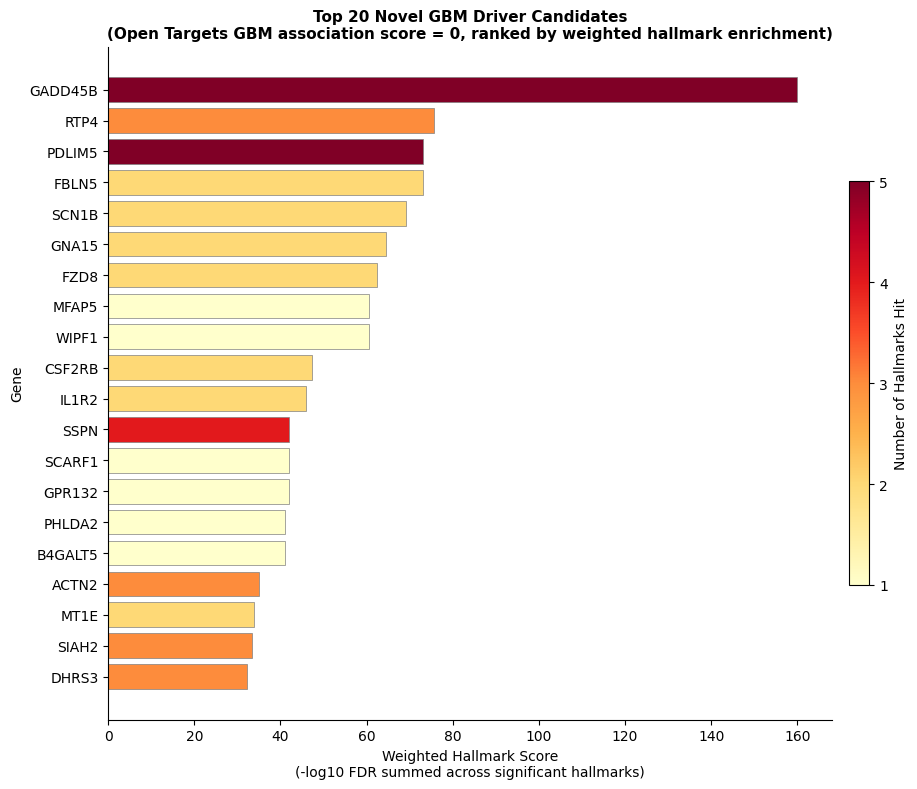

Saved to D:\School\IITD\General\GBM_new\miner_output\output_matrices\top20_novel_candidates.png


In [42]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Filter to novel candidates only (OT score = 0) and take top 20 by weighted score
top_novel = gene_rank_df[
    gene_rank_df['GBM_Status'] == 'Novel Candidate'
].sort_values('WeightedScore', ascending=False).head(20).reset_index(drop=True)

print(top_novel[['Gene', 'WeightedScore', 'N_Hallmarks', 'Top_Hallmarks']].to_string(index=False))

# ── Figure ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))

# Color bars by number of hallmarks
cmap = plt.cm.YlOrRd
norm = plt.Normalize(vmin=top_novel['N_Hallmarks'].min(), vmax=top_novel['N_Hallmarks'].max())
colors = [cmap(norm(n)) for n in top_novel['N_Hallmarks']]

bars = ax.barh(
    top_novel['Gene'][::-1],
    top_novel['WeightedScore'][::-1],
    color=colors[::-1],
    edgecolor='grey',
    linewidth=0.5
)

# Colorbar for N_Hallmarks
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, pad=0.02, shrink=0.6)
cbar.set_label('Number of Hallmarks Hit', fontsize=10)
cbar.ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))

# Labels
ax.set_xlabel('Weighted Hallmark Score\n(-log10 FDR summed across significant hallmarks)', fontsize=10)
ax.set_title(
    'Top 20 Novel GBM Driver Candidates\n'
    '(Open Targets GBM association score = 0, ranked by weighted hallmark enrichment)',
    fontsize=11, fontweight='bold'
)
ax.set_ylabel('Gene', fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()

fig_path = os.path.join(matrices_dir, "top20_novel_candidates.png")
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved to {fig_path}")